# Regression Analysis: Trust vs GDP, Education, Unemployment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools


In [3]:
data = {
    "Country": ["Andorra","Argentina","Brazil","Chile","Colombia","Costa Rica","Ecuador","Kazakhstan","Mexico","Pakistan","Philippines","Puerto Rico","Romania","Uruguay"],
    "Year": [2018]*14,
    "Trust": [30.130722,19.855508,4.509698,13.981507,19.739761,10.194100,15.486740,23.130382,20.311960,23.380464,9.103857,18.186838,10.823018,21.652912],
    "GDP": [1.588765,-2.617396,1.783667,3.990029,2.564324,2.615904,1.044295,4.1,1.972082,6.151703,6.341486,-4.361427,5.394522,0.164778],
    "Education": [11.927510,17.857821,15.503760,16.606211,14.628640,15.228420,14.725050,14.350610,14.923050,7.303080,12.840950,17.554440,14.355550,16.269159],
    "Unemployment": [1.775,9.2,12.375,7.377,9.942,11.951,3.69,4.828,3.321,5.8,5.325,9.2,5.25,8.367]
}

df = pd.DataFrame(data)
print(df.head())


     Country  Year      Trust       GDP  Education  Unemployment
0    Andorra  2018  30.130722  1.588765  11.927510         1.775
1  Argentina  2018  19.855508 -2.617396  17.857821         9.200
2     Brazil  2018   4.509698  1.783667  15.503760        12.375
3      Chile  2018  13.981507  3.990029  16.606211         7.377
4   Colombia  2018  19.739761  2.564324  14.628640         9.942


         Year      Trust        GDP  Education  Unemployment
count    14.0  14.000000  14.000000  14.000000     14.000000
mean   2018.0  17.177676   2.195195  14.576732      7.028643
std       0.0   6.873509   3.068810   2.646935      3.252871
min    2018.0   4.509698  -4.361427   7.303080      1.775000
25%    2018.0  11.612640   1.180413  14.351845      4.933500
50%    2018.0  18.963300   2.268203  14.824050      6.588500
75%    2018.0  21.317674   4.072507  16.077809      9.200000
max    2018.0  30.130722   6.341486  17.857821     12.375000


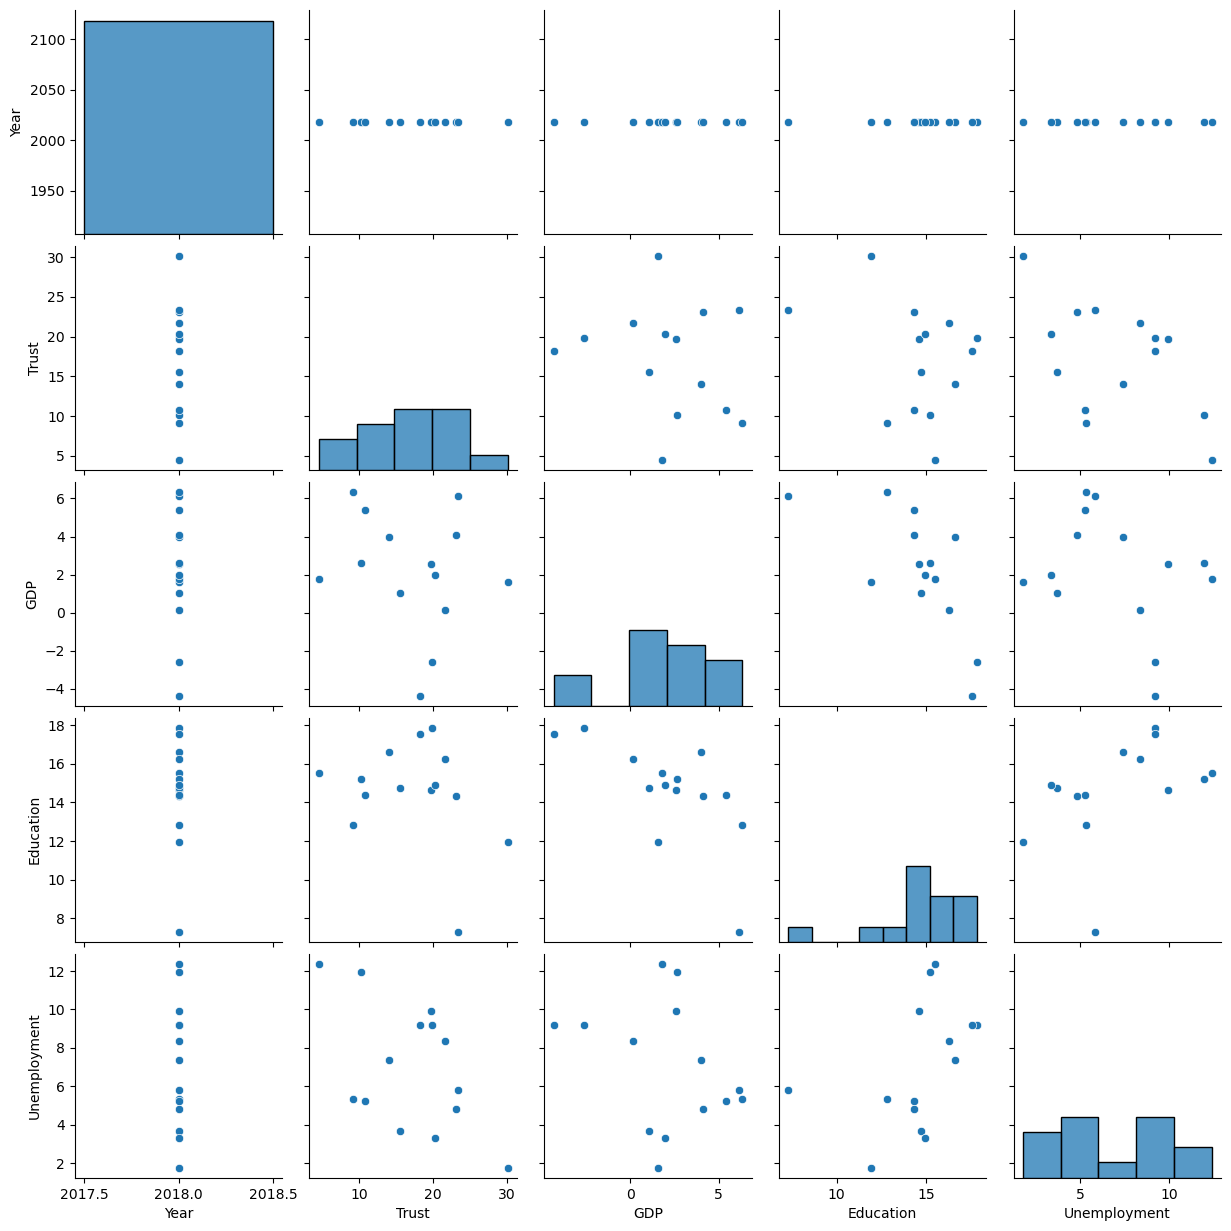

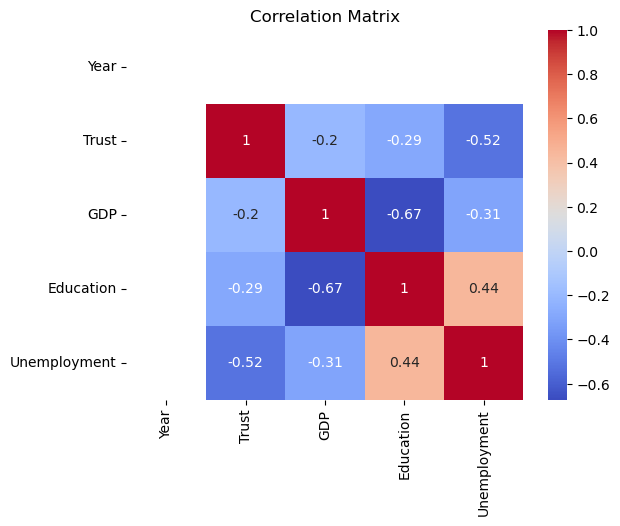

In [4]:
print(df.describe())

sns.pairplot(df)
plt.show()

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The dataset shows considerable variation across countries. Trust levels differ widely, indicating differences in societal confidence. GDP growth ranges from negative to strong positive values, reflecting diverse economic conditions. Education levels are relatively more consistent across countries, while unemployment rates vary moderately. Overall, the variation in these variables makes the dataset suitable for regression analysis.

In [12]:
# 4. Regression Function
def run_model(features):
    X = df[list(features)]
    X = sm.add_constant(X)
    y = df['Trust']
    model = sm.OLS(y, X).fit()
    return model

In [17]:
# Subset Models
features= ['GDP','Education','Unemployment']
results = []

for k in range(1, len(features)+1):
    for combo in itertools.combinations(features, k):
        model = run_model(combo)
        results.append({
            'Model': combo,
            'R2': model.rsquared,
            'Adj_R2': model.rsquared_adj,
            'AIC': model.aic,
            'BIC': model.bic
        })
        print("\nModel:", combo)
        print(model.summary())

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Adj_R2', ascending=False))


Model: ('GDP',)
                            OLS Regression Results                            
Dep. Variable:                  Trust   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                 -0.039
Method:                 Least Squares   F-statistic:                    0.5153
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.487
Time:                        23:28:29   Log-Likelihood:                -46.040
No. Observations:                  14   AIC:                             96.08
Df Residuals:                      12   BIC:                             97.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.1754      2.332   

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.1

## Summary

### 1. Individual Models (1 variable)

* **GDP only**

  * Very low explanatory power (R² = 0.04)
  * Not significant (p = 0.487)
  GDP alone does **not explain trust**

* **Education only**

  * Weak relationship (R² = 0.08)
  * Not significant (p = 0.320)
  Education alone is also **not a strong predictor**

* **Unemployment only**

  * Moderate explanatory power (R² = 0.27)
  * Nearly significant (p ≈ 0.056)
  Higher unemployment tends to **reduce trust**



### 2. Two-Variable Models

* **GDP + Education**

  * R² = 0.37 (improves fit)
  * Both variables significant
  Combined effect improves explanation of trust

* **GDP + Unemployment** 

  * R² = 0.42
  * Unemployment is significant (p = 0.022)
  Stronger model, unemployment is key driver

* **Education + Unemployment**

  * Weak model (Adj R² = 0.14)
  Not very useful



### 3. Full Model (Best Model) 

**GDP + Education + Unemployment**

* **R² = 0.566 (highest)**
* **Adjusted R² = 0.436 (best overall)**
* **Lowest AIC = 88.99 → best model fit**

### Key findings:

* **GDP:** Significant negative effect (p = 0.027)
* **Unemployment:** Marginally significant negative effect (p ≈ 0.058)
* **Education:** Not statistically significant

Interpretation:

* Higher unemployment → lower trust
* GDP shows a negative relationship (unexpected but data-driven)
* Education has weaker influence when other variables are included



### Final Conclusion

The full model including GDP, Education, and Unemployment provides the best overall fit. Among the variables, unemployment is the most consistent predictor of trust, showing a negative relationship. GDP also appears significant in the full model, while education has a weaker effect. Overall, economic conditions, especially unemployment, play a more important role in explaining trust levels across countries.



### Simple Explanation 

Countries where more people are unemployed tend to have lower trust. Economic growth and education matter, but unemployment seems to have the strongest impact on how much people trust institutions.


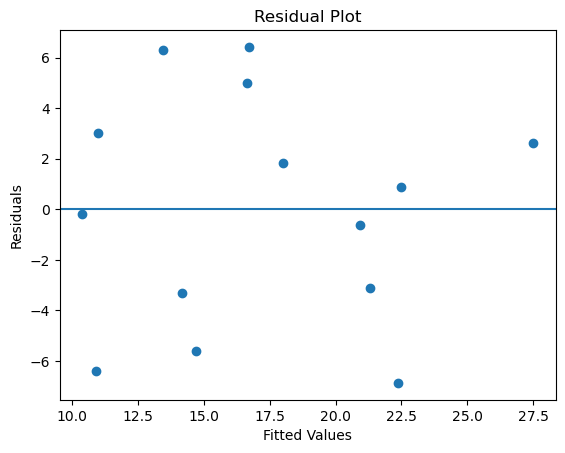

In [18]:
# 6. Full Model Diagnostics
full_model = run_model(features)

# Residuals
residuals = full_model.resid
fitted = full_model.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

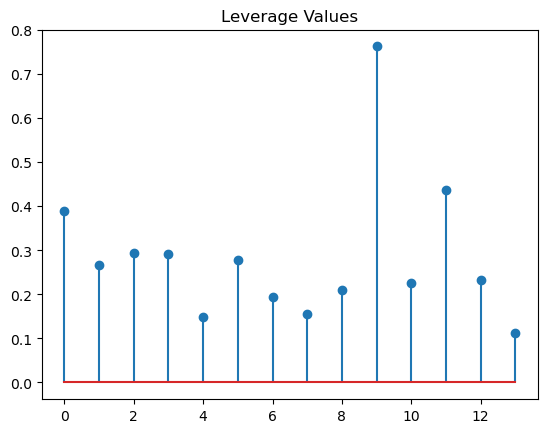

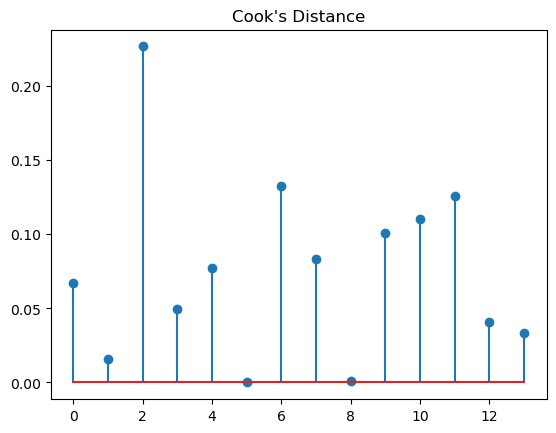

In [19]:
# 7. Leverage & Influence
influence = full_model.get_influence()
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]

plt.stem(leverage)
plt.title("Leverage Values")
plt.show()

plt.stem(cooks)
plt.title("Cook's Distance")
plt.show()

In [20]:
# Identify influential points
threshold = 4/len(df)
influential_points = np.where(cooks > threshold)[0]
print("Influential Points Index:", influential_points)
print(df.iloc[influential_points])

Influential Points Index: []
Empty DataFrame
Columns: [Country, Year, Trust, GDP, Education, Unemployment]
Index: []


In [21]:
# 8. Final Model Selection
best_model = results_df.sort_values(by='Adj_R2', ascending=False).iloc[0]
print("Best Model Based on Adjusted R2:")
print(best_model)

Best Model Based on Adjusted R2:
Model     (GDP, Education, Unemployment)
R2                              0.565898
Adj_R2                          0.435667
AIC                            88.985003
BIC                            91.541232
Name: 6, dtype: object


## Final Conclusion:   
This study examined the relationship between trust and three key factors: GDP, education, and unemployment across 14 countries in 2018. The results show that individual variables such as GDP and education alone do not significantly explain variations in trust. However, when combined in a multiple regression model, the explanatory power improves substantially.


Among all models tested, the full model (GDP, Education, and Unemployment) was identified as the optimal model based on the highest adjusted R² and lowest AIC. This indicates that trust is influenced by a combination of economic and social factors rather than any single variable.

The analysis reveals that unemployment has the most consistent negative relationship with trust, suggesting that higher unemployment levels are associated with lower public confidence. GDP also shows a statistically significant effect in the full model, although its negative relationship may reflect underlying complexities in the data. Education, while theoretically important, was not found to be a strong predictor in this dataset.

Diagnostic checks confirmed that the regression assumptions are reasonably satisfied, with no major issues of non-linearity or influential outliers. Therefore, all observations were retained in the analysis.